In [10]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import time

In [11]:
ctype = np.float64

### `init_grid` 
input: `shape`: (shape of a grid) ; `threshold`: density of the living cells 
output: `grid` 2darray of boolean 
initialize a random grid (2darray) of double float of dimension shape (the threshold help to define density)

In [9]:
def init_grid(shape, threshold=0.50):
    """
    initialize a random  grid of double float 
    of dimension shape (the threshold help to define density)
    """
    x = np.zeros(shape,dtype=ctype)
    r = np.random.random(shape)
    x[:,:] = (r> 1.0 - threshold)
    return x

In [5]:
def get_nbneigh(grid, coord):
    irange, jrange = grid.shape
    i, j = coord
    biinf = max(0, i - 1)
    bisup = min(irange - 1, i + 1)
    bjinf = max(0,j - 1)
    bjsup = min(jrange - 1,j + 1)
    nb_neigh = 0
    # loop over neighs to count living cells
    for ii in range(biinf, bisup + 1):
        for jj in range(bjinf, bjsup + 1):
            if grid[ii, jj]:
                nb_neigh = nb_neigh + 1
    # in my count I count current cell itself substract the value
    nb_neigh = nb_neigh-grid[i, j]
    return nb_neigh

### `life_step(grid)` : 
- input: `grid` a 2darray of cells (boolean); 
- output: `res_grid`  2darray ; the state of each cell of `grid` resulting from the application of the rules

In [6]:
def life_step(grid):
    irange, jrange = grid.shape
    res_grid = np.zeros(grid.shape,dtype=ctype)
    for j in range(jrange):
        for i in range(irange):
            # by default cell_state is dead
            cell_state = False
            # loop over neighs to count living cells
            nb_neigh = get_nbneigh(grid,(i,j))
            # if 2 neighbors cell state isn't modified
            if nb_neigh == 2:
                cell_state = grid[i, j]
            # if 3 neighbors cell state is alive
            elif nb_neigh == 3:
                cell_state = 1
            # in other case cell state is dead (default state)
            res_grid[i, j] = cell_state
    return res_grid

### `conway(grid,n)`
From an initial grid, run n iterations of evolution and display the intermediate statistics (number of alive cells)

In [7]:
def conway(grid, n):
    """
    From an initial grid, run n iterations of evolution and display 
    the intermediate statistics (number of alive cells)
    """
    for i in range(n):
        alive = np.sum(grid)
        print(f'alive cells: {alive:.0f}: {alive / grid.size * 100:2.2f}%')
        grid = life_step(grid)
    return grid

### Exemple on a little grid

In [7]:
grid = init_grid((10,10), 0.5)

In [8]:
grid

array([[1., 1., 1., 0., 0., 1., 1., 0., 1., 0.],
       [1., 1., 1., 0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 1., 0., 1., 1., 1., 0., 1.],
       [0., 1., 1., 0., 0., 0., 0., 1., 0., 1.],
       [1., 0., 1., 1., 1., 0., 0., 0., 0., 1.],
       [0., 1., 0., 1., 0., 1., 1., 0., 1., 0.],
       [1., 0., 0., 0., 1., 1., 0., 1., 0., 0.],
       [1., 1., 1., 0., 1., 1., 0., 0., 1., 1.],
       [0., 1., 1., 0., 0., 0., 0., 1., 1., 1.],
       [1., 1., 0., 0., 1., 1., 0., 1., 1., 1.]])

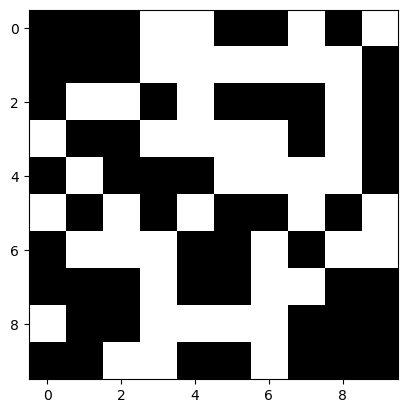

In [10]:
plt.imshow(grid,cmap=plt.cm.binary)

In [11]:
grid = life_step(grid)

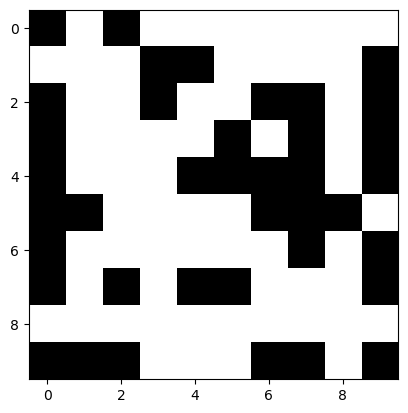

In [12]:
plt.imshow(grid,cmap=plt.cm.binary)

In [13]:
conway(grid,5)

alive cells: 39: 39.00%
alive cells: 33: 33.00%
alive cells: 37: 37.00%
alive cells: 30: 30.00%
alive cells: 34: 34.00%


array([[0., 0., 0., 0., 1., 0., 0., 0., 1., 0.],
       [0., 1., 0., 1., 1., 0., 0., 0., 0., 1.],
       [1., 0., 1., 0., 0., 1., 1., 0., 0., 1.],
       [1., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 0., 0., 0., 0., 0., 0., 1., 1.],
       [0., 1., 1., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 1., 0., 0., 0., 0., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

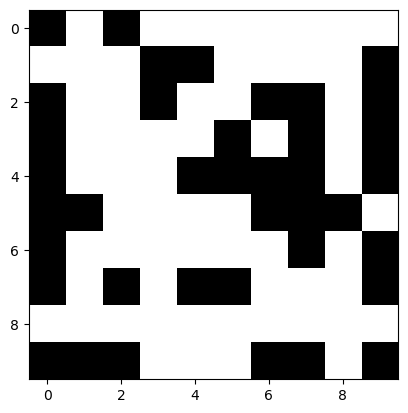

In [14]:
plt.imshow(grid,cmap=plt.cm.binary)

## Question 1.a 
Utilisez le notebook avec différentes tailles progressivement croissantes ((10,10) (100,100), (1000, 1000), (2000, 2000), …) et estimer les temps d’exécution de `conway` avec la commande magique `%time`

In [17]:
values_n = [10, 50, 100, 250, 500, 750, 1000, 1250, 1500, 1750, 2000]
times = []

for n in values_n:

    grid = init_grid((n,n), 0.5)

    print("----- n = ",n," -----")  
    tic = time.time()
    %time conway(grid,5)
    toc = time.time()
    elapsed_time = toc - tic
    times.append(elapsed_time)

----- n =  10  -----
alive cells: 52: 52.00%
alive cells: 28: 28.00%
alive cells: 25: 25.00%
alive cells: 25: 25.00%
alive cells: 25: 25.00%
CPU times: user 1.51 ms, sys: 0 ns, total: 1.51 ms
Wall time: 1.51 ms
----- n =  50  -----
alive cells: 1226: 49.04%
alive cells: 802: 32.08%
alive cells: 702: 28.08%
alive cells: 641: 25.64%
alive cells: 580: 23.20%
CPU times: user 36 ms, sys: 993 µs, total: 37 ms
Wall time: 35.7 ms
----- n =  100  -----
alive cells: 4965: 49.65%
alive cells: 2848: 28.48%
alive cells: 2789: 27.89%
alive cells: 2717: 27.17%
alive cells: 2453: 24.53%
CPU times: user 80.7 ms, sys: 0 ns, total: 80.7 ms
Wall time: 80.7 ms
----- n =  250  -----
alive cells: 31200: 49.92%
alive cells: 17411: 27.86%
alive cells: 16141: 25.83%
alive cells: 15813: 25.30%
alive cells: 14934: 23.89%
CPU times: user 489 ms, sys: 998 µs, total: 490 ms
Wall time: 490 ms
----- n =  500  -----
alive cells: 125089: 50.04%
alive cells: 68432: 27.37%
alive cells: 63431: 25.37%
alive cells: 62400: 24

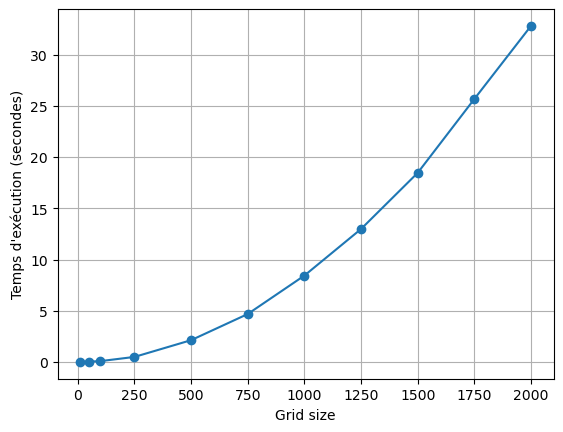

In [18]:
plt.plot(values_n, times, marker='o')
plt.xlabel('Grid size')
plt.ylabel("Temps d'exécution (secondes)")
plt.grid(True)
plt.show()

# Questions 2 cProfile

In [8]:
import cProfile

## Question 2.a 
Utilisez `cProfile` afin de réaliser un profilage du code (sur des grilles ayant un temps de restitution de quelques secondes ~1000x1000). Que remarquez-vous sur les fonctions les plus coûteuses ?

In [9]:
grid = init_grid((1000,1000), 0.5)

cProfile.run('conway(grid,5)', sort='ncalls')

alive cells: 499431: 49.94%
alive cells: 274636: 27.46%
alive cells: 253962: 25.40%
alive cells: 249663: 24.97%
alive cells: 238376: 23.84%
         25002805 function calls (25002804 primitive calls) in 11.536 seconds

   Ordered by: call count

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
 10000043    1.046    0.000    1.046    0.000 {built-in method builtins.max}
 10000016    1.030    0.000    1.030    0.000 {built-in method builtins.min}
  5000000    7.905    0.000    9.981    0.000 3970450040.py:1(get_nbneigh)
      510    0.000    0.000    0.000    0.000 {built-in method builtins.isinstance}
      210    0.000    0.000    0.000    0.000 enum.py:1544(_get_value)
      116    0.000    0.000    0.000    0.000 {built-in method builtins.len}
      100    0.000    0.000    0.000    0.000 enum.py:1129(__new__)
      100    0.000    0.000    0.000    0.000 enum.py:726(__call__)
       75    0.000    0.000    0.000    0.000 traitlets.py:643(get)
       75    0.00

## Question 2.b 
Quel surcoût en temps d’exécution observez-vous par rapport à une exécution sans profilage ?

## Question 2.c 
Générez la sortie du profilage dans un fichier `conway_01.prof`

In [ ]:
cProfile.run('conway(grid,5)', 'conway_01.prof')

alive cells: 499689: 49.97%
alive cells: 274894: 27.49%
alive cells: 253420: 25.34%
alive cells: 250218: 25.02%
alive cells: 237749: 23.77%


# Questions 3 optimisation 1 Inlining

## Question 3.a 
Créez une fonction `life_step_in` qui est une intégration du corps de `get_nbneigh` dans `life_step` et modifiez `conway` pour utiliser `life_step_in` à la place de `life_step`.

In [10]:
def life_step_in(grid):
    irange, jrange = grid.shape
    res_grid = np.zeros(grid.shape,dtype=ctype)
    for j in range(jrange):
        for i in range(irange):
            # by default cell_state is dead
            cell_state = False
            
            
            #### GET_NBNEIGH ####

            irange, jrange = grid.shape
            biinf = max(0, i - 1)
            bisup = min(irange - 1, i + 1)
            bjinf = max(0,j - 1)
            bjsup = min(jrange - 1,j + 1)
            nb_neigh = 0
            # loop over neighs to count living cells
            for ii in range(biinf, bisup + 1):
                for jj in range(bjinf, bjsup + 1):
                    if grid[ii, jj]:
                        nb_neigh = nb_neigh + 1
            # in my count I count current cell itself substract the value
            nb_neigh = nb_neigh-grid[i, j]


            # if 2 neighbors cell state isn't modified
            if nb_neigh == 2:
                cell_state = grid[i, j]
            # if 3 neighbors cell state is alive
            elif nb_neigh == 3:
                cell_state = 1
            # in other case cell state is dead (default state)
            res_grid[i, j] = cell_state
    return res_grid

In [ ]:
def conway_in(grid, n):
    """
    From an initial grid, run n iterations of evolution and display 
    the intermediate statistics (number of alive cells)
    """
    for i in range(n):
        alive = np.sum(grid)
        print(f'alive cells: {alive:.0f}: {alive / grid.size * 100:2.2f}%')
        grid = life_step_in(grid)
    return grid

## Question 3.b 
Estimez les temps d’exécution de cette nouvelle version et réalisez un profilage avec `cProfile`. Que constatez vous sur les performances ?

In [19]:
for n in values_n:

    grid = init_grid((n,n), 0.5)

    print("----- n = ",n," -----")  
    %time conway_in(grid,5)

----- n =  10  -----


NameError: name 'conway_in' is not defined

----- n =  50  -----


NameError: name 'conway_in' is not defined

----- n =  100  -----


...

NameError: name 'conway_in' is not defined

----- n =  1750  -----


NameError: name 'conway_in' is not defined

----- n =  2000  -----


NameError: name 'conway_in' is not defined

In [16]:
grid = init_grid((1000,1000), 0.5)

cProfile.run('conway_in(grid,5)', sort='ncalls')

alive cells: 499442: 49.94%
alive cells: 274888: 27.49%
alive cells: 255061: 25.51%
alive cells: 251534: 25.15%
alive cells: 239573: 23.96%
         20002874 function calls (20002862 primitive calls) in 11.115 seconds

   Ordered by: call count

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
 10000043    1.090    0.000    1.090    0.000 {built-in method builtins.max}
 10000016    1.066    0.000    1.066    0.000 {built-in method builtins.min}
      517    0.000    0.000    0.000    0.000 {built-in method builtins.isinstance}
      210    0.000    0.000    0.000    0.000 enum.py:1544(_get_value)
      118    0.000    0.000    0.000    0.000 {built-in method builtins.len}
      100    0.000    0.000    0.000    0.000 enum.py:1129(__new__)
      100    0.000    0.000    0.000    0.000 enum.py:726(__call__)
       77    0.000    0.000    0.000    0.000 traitlets.py:643(get)
       77    0.000    0.000    0.000    0.000 traitlets.py:675(__get__)
       45    0.057  

# Questions 4 Profilage life_step_in

## Question 4.a 
Avec line_profiler, profilez ligne à ligne la fonction life_step_in en ne jouant qu’une seule itération. 

In [2]:
pip install line_profiler

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [1]:
from line_profiler import profile

ModuleNotFoundError: No module named 'line_profiler'

## Question 4.b
Quel surcoût en temps d’exécution observez-vous par rapport à une exécution sans profilage ?

## Question 4.c
Quels sont les hot spots mis en évidence par le profilage ligne à ligne ?